<a href="https://colab.research.google.com/github/AufanT/2411532011---Desain-Web---AufanT/blob/main/Praktikum5/TugasCrossValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

TRAIN_URL = "https://raw.githubusercontent.com/AufanT/AufanTaufiqurrahman_2411532011_ML2526/refs/heads/main/train.csv"
TEST_URL = "https://raw.githubusercontent.com/AufanT/AufanTaufiqurrahman_2411532011_ML2526/refs/heads/main/test.csv"
LABEL_URL = "https://raw.githubusercontent.com/AufanT/AufanTaufiqurrahman_2411532011_ML2526/refs/heads/main/gender_submission.csv"

df_train = pd.read_csv(TRAIN_URL)
df_test = pd.read_csv(TEST_URL)
df_label = pd.read_csv(LABEL_URL)

print("Train shape :", df_train.shape)
print("Test shape  :", df_test.shape)
print("Label shape :", df_label.shape)

df_train.head()

Train shape : (891, 12)
Test shape  : (418, 11)
Label shape : (418, 2)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Info Train Dataset:")
print(df_train.info())
print("\nMissing Values (Train):")
print(df_train.isnull().sum())
print("\nMissing Values (Test):")
print(df_test.isnull().sum())

Info Train Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values (Train):
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabi

In [4]:
def preprocess(df, is_train=True):
    df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
    df['Age'].fillna(df['Age'].median(), inplace=True)
    df['Fare'].fillna(df['Fare'].median(), inplace=True)
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    le = LabelEncoder()
    df['Sex'] = le.fit_transform(df['Sex'])
    df['Embarked'] = le.fit_transform(df['Embarked'])
    if is_train:
        return df.drop('Survived', axis=1), df['Survived']
    else:
        return df

X, y = preprocess(df_train.copy(), is_train=True)
X_holdout = preprocess(df_test.copy(), is_train=False)
y_holdout = df_label['Survived']

print("Fitur train :", X.shape)
print("Holdout test:", X_holdout.shape)
print("\nDistribusi Target (Train):")
print(y.value_counts())

Fitur train : (891, 7)
Holdout test: (418, 7)

Distribusi Target (Train):
Survived
0    549
1    342
Name: count, dtype: int64


In [5]:
print("Fitur:", X.columns.tolist())
print("\nDistribusi Target (Train):")
print(y.value_counts())
print("\nDistribusi Target (Holdout/gender_submission):")
print(y_holdout.value_counts())

Fitur: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Distribusi Target (Train):
Survived
0    549
1    342
Name: count, dtype: int64

Distribusi Target (Holdout/gender_submission):
Survived
0    266
1    152
Name: count, dtype: int64


In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_lr = LogisticRegression(max_iter=1000)

metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model_lr.fit(X_train, y_train)
    y_pred = model_lr.predict(X_test)

    metrics['accuracy'].append(accuracy_score(y_test, y_pred))
    metrics['precision'].append(precision_score(y_test, y_pred))
    metrics['recall'].append(recall_score(y_test, y_pred))
    metrics['f1'].append(f1_score(y_test, y_pred))

    print(f"Fold {fold} | Acc: {metrics['accuracy'][-1]:.4f} | "
          f"Prec: {metrics['precision'][-1]:.4f} | "
          f"Recall: {metrics['recall'][-1]:.4f} | "
          f"F1: {metrics['f1'][-1]:.4f}")

print("\n=== Rata-rata Logistic Regression ===")
for m, vals in metrics.items():
    print(f"{m.capitalize():10s}: {np.mean(vals):.4f} (+/- {np.std(vals):.4f})")

Fold 1 | Acc: 0.7654 | Prec: 0.6901 | Recall: 0.7101 | F1: 0.7000
Fold 2 | Acc: 0.8034 | Prec: 0.7705 | Recall: 0.6912 | F1: 0.7287
Fold 3 | Acc: 0.7921 | Prec: 0.7719 | Recall: 0.6471 | F1: 0.7040
Fold 4 | Acc: 0.7809 | Prec: 0.7101 | Recall: 0.7206 | F1: 0.7153
Fold 5 | Acc: 0.8258 | Prec: 0.7794 | Recall: 0.7681 | F1: 0.7737

=== Rata-rata Logistic Regression ===
Accuracy  : 0.7935 (+/- 0.0205)
Precision : 0.7444 (+/- 0.0368)
Recall    : 0.7074 (+/- 0.0394)
F1        : 0.7243 (+/- 0.0266)


In [7]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

metrics_rf = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model_rf.fit(X_train, y_train)
    y_pred = model_rf.predict(X_test)

    metrics_rf['accuracy'].append(accuracy_score(y_test, y_pred))
    metrics_rf['precision'].append(precision_score(y_test, y_pred))
    metrics_rf['recall'].append(recall_score(y_test, y_pred))
    metrics_rf['f1'].append(f1_score(y_test, y_pred))

    print(f"Fold {fold} | Acc: {metrics_rf['accuracy'][-1]:.4f} | "
          f"Prec: {metrics_rf['precision'][-1]:.4f} | "
          f"Recall: {metrics_rf['recall'][-1]:.4f} | "
          f"F1: {metrics_rf['f1'][-1]:.4f}")

print("\n=== Rata-rata Random Forest ===")
for m, vals in metrics_rf.items():
    print(f"{m.capitalize():10s}: {np.mean(vals):.4f} (+/- {np.std(vals):.4f})")

Fold 1 | Acc: 0.8380 | Prec: 0.8226 | Recall: 0.7391 | F1: 0.7786
Fold 2 | Acc: 0.8146 | Prec: 0.7397 | Recall: 0.7941 | F1: 0.7660
Fold 3 | Acc: 0.7865 | Prec: 0.7273 | Recall: 0.7059 | F1: 0.7164
Fold 4 | Acc: 0.8202 | Prec: 0.7727 | Recall: 0.7500 | F1: 0.7612
Fold 5 | Acc: 0.8371 | Prec: 0.8125 | Recall: 0.7536 | F1: 0.7820

=== Rata-rata Random Forest ===
Accuracy  : 0.8193 (+/- 0.0188)
Precision : 0.7750 (+/- 0.0379)
Recall    : 0.7486 (+/- 0.0283)
F1        : 0.7608 (+/- 0.0235)


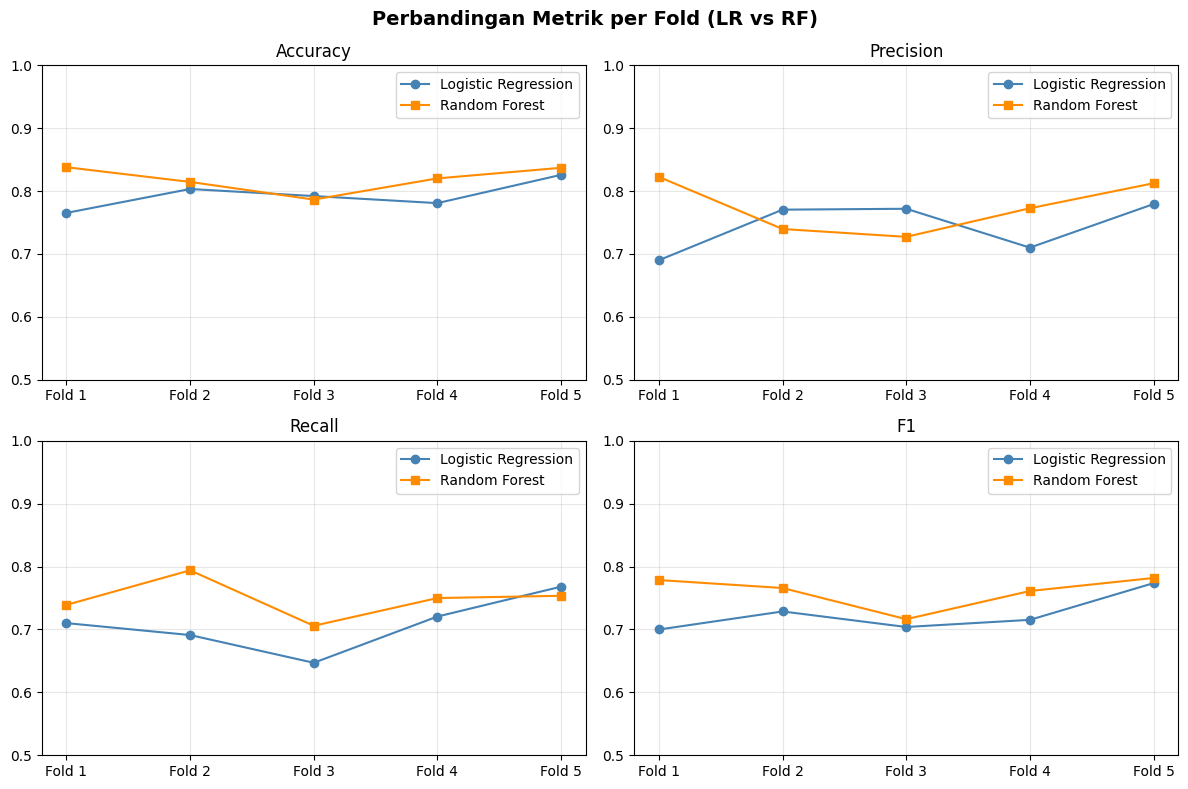

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Perbandingan Metrik per Fold (LR vs RF)', fontsize=14, fontweight='bold')

fold_labels = [f'Fold {i}' for i in range(1, 6)]
metric_names = ['accuracy', 'precision', 'recall', 'f1']

for ax, metric in zip(axes.flatten(), metric_names):
    ax.plot(fold_labels, metrics[metric], marker='o', label='Logistic Regression', color='steelblue')
    ax.plot(fold_labels, metrics_rf[metric], marker='s', label='Random Forest', color='darkorange')
    ax.set_title(metric.capitalize())
    ax.set_ylim(0.5, 1.0)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

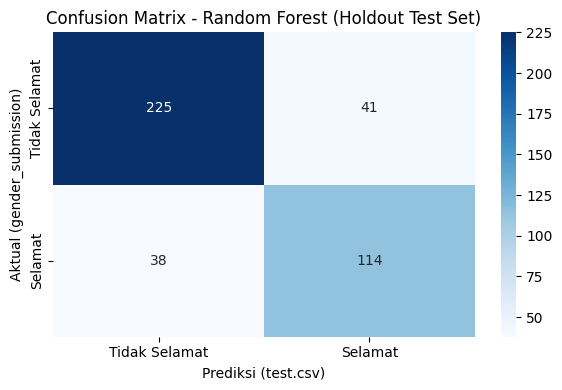


Classification Report (Holdout Test Set):
               precision    recall  f1-score   support

Tidak Selamat       0.86      0.85      0.85       266
      Selamat       0.74      0.75      0.74       152

     accuracy                           0.81       418
    macro avg       0.80      0.80      0.80       418
 weighted avg       0.81      0.81      0.81       418



In [9]:
model_rf.fit(X, y)
y_pred_holdout = model_rf.predict(X_holdout)

cm = confusion_matrix(y_holdout, y_pred_holdout)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Selamat', 'Selamat'],
            yticklabels=['Tidak Selamat', 'Selamat'])
plt.title('Confusion Matrix - Random Forest (Holdout Test Set)')
plt.ylabel('Aktual (gender_submission)')
plt.xlabel('Prediksi (test.csv)')
plt.tight_layout()
plt.show()

print("\nClassification Report (Holdout Test Set):")
print(classification_report(y_holdout, y_pred_holdout, target_names=['Tidak Selamat', 'Selamat']))

In [10]:
summary = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [
        f"{np.mean(metrics['accuracy']):.4f} ± {np.std(metrics['accuracy']):.4f}",
        f"{np.mean(metrics['precision']):.4f} ± {np.std(metrics['precision']):.4f}",
        f"{np.mean(metrics['recall']):.4f} ± {np.std(metrics['recall']):.4f}",
        f"{np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}"
    ],
    'Random Forest': [
        f"{np.mean(metrics_rf['accuracy']):.4f} ± {np.std(metrics_rf['accuracy']):.4f}",
        f"{np.mean(metrics_rf['precision']):.4f} ± {np.std(metrics_rf['precision']):.4f}",
        f"{np.mean(metrics_rf['recall']):.4f} ± {np.std(metrics_rf['recall']):.4f}",
        f"{np.mean(metrics_rf['f1']):.4f} ± {np.std(metrics_rf['f1']):.4f}"
    ]
})

print("=== Ringkasan Hasil K-Fold Cross Validation (5 Fold) ===")
print(summary.to_string(index=False))

=== Ringkasan Hasil K-Fold Cross Validation (5 Fold) ===
   Metrik Logistic Regression   Random Forest
 Accuracy     0.7935 ± 0.0205 0.8193 ± 0.0188
Precision     0.7444 ± 0.0368 0.7750 ± 0.0379
   Recall     0.7074 ± 0.0394 0.7486 ± 0.0283
 F1-Score     0.7243 ± 0.0266 0.7608 ± 0.0235
